In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, TargetEncoder

from lightgbm import LGBMRegressor
import lightgbm as lgb

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv", low_memory=False)
test_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv", low_memory=False)

print("Train Shape:", train_df.shape)
print("Test Shape: ", test_df.shape)

Train Shape: (138701, 50)
Test Shape:  (15000, 49)


# Exploratory Data Analysis (EDA)

## Data Inspect

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

## Stats Summary

In [5]:
display(train_df.describe())

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


## Missing value Analysis

In [6]:
missing_pct = (train_df.isnull().sum() / len(train_df)) * 100
missing_table = pd.DataFrame({'Missing %': missing_pct}).sort_values(by='Missing %', ascending=False)

print(missing_table.head(10))

       Missing %
col19  99.952416
col18  99.952416
col5   92.515555
col4   92.515555
col27  89.214930
col28  89.214930
col29  86.393753
col30  86.393753
col13  83.125572
col14  83.125572


## Missing Value - Visualization

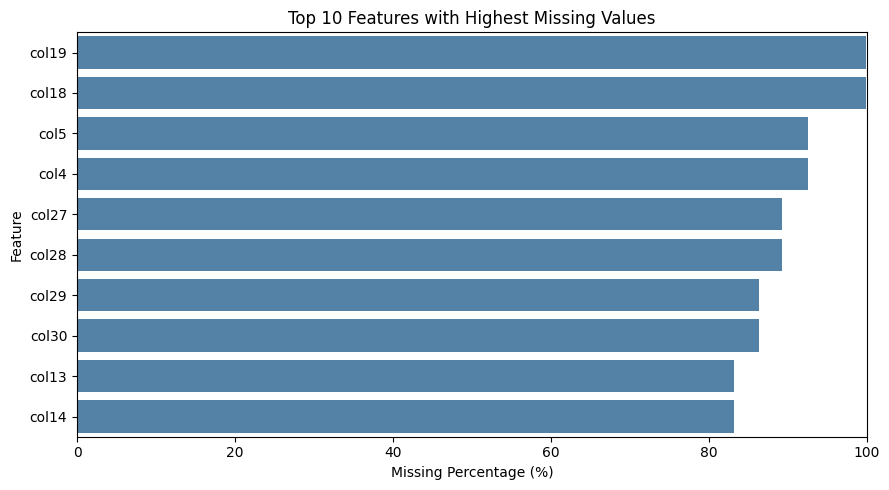

In [7]:
missing_plot = missing_table.head(10)

plt.figure(figsize=(9,5))

sns.barplot(
    x=missing_plot["Missing %"],
    y=missing_plot.index,
    color="steelblue"
)

plt.title("Top 10 Features with Highest Missing Values")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Target Price Distribution

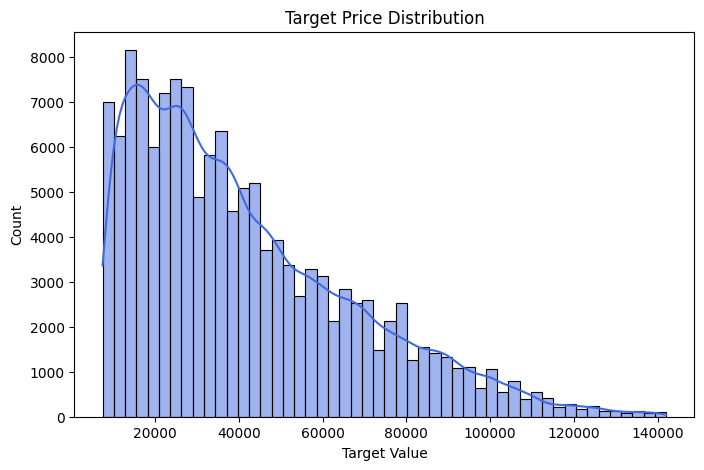

In [8]:
target = train_df["TargetValue"]

plt.figure(figsize=(8,5))

sns.histplot(
    train_df["TargetValue"],
    bins=50,
    kde=True,
    color="royalblue"
)

plt.title("Target Price Distribution")
plt.xlabel("Target Value")
plt.ylabel("Count")

plt.show()

## Correlation Analysis of Numerical Features

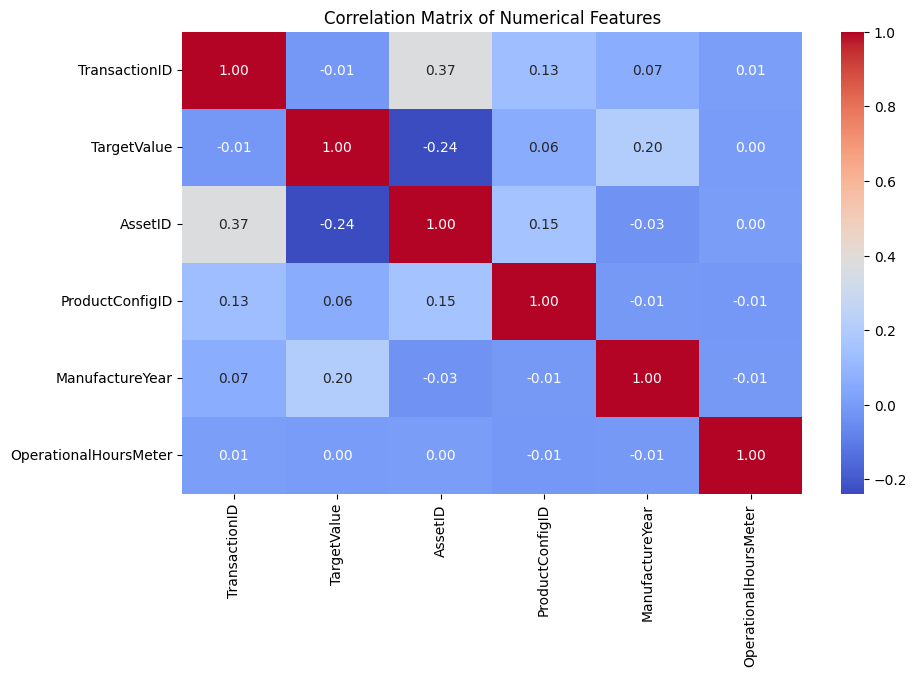

In [9]:
plt.figure(figsize=(10,6))

corr = train_df.select_dtypes(include=["number"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

Most numerical features have weak linear correlations with the target variable.

manufacture Year shows a weak positive correlation (0.20) with the selling price, indicating that newer machines tend to have slightly higher prices.

no pair of numerical features shows a very high correlation.

correlations are generally weak, additional feature engineering may help capture more complex relationships in 
the data.

# Train-Validation Split

In [10]:
y_full = np.log(train_df["TargetValue"])
X_raw = train_df.drop(columns=["TargetValue"])
X_test_raw = test_df.copy()

X_train, X_val, y_train, y_val = train_test_split(X_raw, y_full, test_size=0.10, random_state=42)

print( X_train.shape )
print( X_val.shape )

(124830, 49)
(13871, 49)


Performing the split at this stage helps prevent data leakage, as all preprocessing steps (such as imputation, encoding, and scaling) are learned only from the training data and then applied to the validation and test sets.

The target variable is log-transformed before training.... to reduce skewness and support the RMSLE metric.

# Feature Engineering

In [11]:
X_tr = X_train.copy()
X_va = X_val.copy()
X_te = X_test_raw.copy()

## Date Based Feature engg.

In [12]:
for df in [X_tr, X_va, X_te]:
    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
    df["sale_year"] = df["TransactionDate"].dt.year
    df["sale_month"] = df["TransactionDate"].dt.month
    df["DateElapsed"] = (df["TransactionDate"] - pd.to_datetime("1990-01-01")).dt.days
    df.drop(columns=["TransactionDate"], inplace=True)

## Machine Age Feature enggg.

In [13]:
for df in [X_tr, X_va, X_te]:

    df["ManufactureYear"] = df["ManufactureYear"].replace(1001, np.nan)
    df["machine_age"] = (df["sale_year"] - df["ManufactureYear"]).clip(lower=0)
    df["machine_age"] = (df["machine_age"].fillna(df["machine_age"].median()))

## Equipment Usage Feature Engg.

In [14]:
for df in [X_tr, X_va, X_te]:

    df["OperationalHoursMeter"] = (df["OperationalHoursMeter"].fillna(df["OperationalHoursMeter"].median()))
    df["hours_per_year"] = (df["OperationalHoursMeter"] /(df["machine_age"] + 1))
    df["age_x_hours"] = (df["machine_age"] *df["OperationalHoursMeter"])
    df["log_hours"] = np.log1p(df["OperationalHoursMeter"])

In [15]:
for df in [X_tr, X_va, X_te]:

    df["age_squared"] = df["machine_age"] ** 2
    df["log_age"] = np.log1p(df["machine_age"])
    df["age_log_hours"] = df["machine_age"] * df["log_hours"]

    df["sale_month_sin"] = np.sin(2 * np.pi * df["sale_month"] / 12)
    df["sale_month_cos"] = np.cos(2 * np.pi * df["sale_month"] / 12)

    df["hours_squared"] = df["OperationalHoursMeter"] ** 2
    df["log_hours_per_year"] = np.log1p(df["hours_per_year"])
    df["age_div_hours"] = df["machine_age"] / (df["OperationalHoursMeter"] + 1)

In [16]:
for df in [X_tr, X_va, X_te]:

    df["date_x_age"] = df["DateElapsed"] * df["machine_age"]
    df["date_x_hours"] = df["DateElapsed"] * df["OperationalHoursMeter"]

In [17]:
# Maintain same feature order across all datasets
X_va = X_va[X_tr.columns]
X_te = X_te[X_tr.columns]

print("Donee")

Donee


Sooo Now.... the validation and test datasets are aligned with the training dataset to ensure that all datasets contain the same feature columns in the same order before model training.

# Data Preprocessing

In [18]:
missing_cols = [c for c in X_tr.columns if X_tr[c].isnull().sum() > 0]

for col in missing_cols:
    X_tr[col+"_missing"] = X_tr[col].isnull().astype(int)
    X_va[col+"_missing"] = X_va[col].isnull().astype(int)
    X_te[col+"_missing"] = X_te[col].isnull().astype(int)

# Align columns after adding flags
X_va = X_va[X_tr.columns]
X_te = X_te[X_tr.columns]

print("Missing indicators generated:", len(missing_cols))

Missing indicators generated: 35


## Dynamic Column Detection

In [19]:
cat_cols = []
num_cols = []

for col in X_tr.columns:
    if X_tr[col].dtype in ['object', 'category']:
        cat_cols.append(col)
    else:
        num_cols.append(col)

# Convert categorical columns to string for TargetEncoder
for col in cat_cols:
    X_tr[col] = X_tr[col].astype(str)
    X_va[col] = X_va[col].astype(str)
    X_te[col] = X_te[col].astype(str)

print("Categorical columns detected:", len(cat_cols))
print("Numerical columns detected:", len(num_cols))

Categorical columns detected: 43
Numerical columns detected: 57


## Preprocessing Pipeline

In [20]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())       
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', TargetEncoder(smooth=0.0, cv=5, random_state=42))
])

# Combine steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)
print("Pipeline successfully defined.")

Pipeline successfully defined.


## Fit and Transform Split Datasets

In [21]:
X_tr_trans = preprocessor.fit_transform(X_tr, y_train)
X_va_trans = preprocessor.transform(X_va)
X_te_trans = preprocessor.transform(X_te)

all_feature_names = num_cols + cat_cols
X_tr = pd.DataFrame(X_tr_trans, columns=all_feature_names)
X_va = pd.DataFrame(X_va_trans, columns=all_feature_names)
X_te = pd.DataFrame(X_te_trans, columns=all_feature_names)

print("Data preprocessing Success")

Data preprocessing Success


# Model Training

## LightGBM

In [22]:
model_lgb = lgb.LGBMRegressor(
    n_estimators=15000, 
    learning_rate=0.008, 
    num_leaves=1023,           
    feature_fraction=0.80,
    subsample=0.80,
    subsample_freq=1,
    min_child_samples=20,        
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42, 
    verbose=-1
)
model_lgb.fit(X_tr, y_train)
preds_lgb = model_lgb.predict(X_va)
score_lgb = np.sqrt(np.mean((y_val - preds_lgb)**2))
print(f"LightGBM Validation RMSLE: {score_lgb:.5f}")

LightGBM Validation RMSLE: 0.20055


## XGBoost

In [23]:
model_xgb = XGBRegressor(
    n_estimators=12000, 
    learning_rate=0.008, 
    max_depth=11,               
    subsample=0.80,
    colsample_bytree=0.80,
    random_state=42, 
    n_jobs=-1
)
model_xgb.fit(X_tr, y_train)
preds_xgb = model_xgb.predict(X_va)
score_xgb = np.sqrt(np.mean((y_val - preds_xgb)**2))
print(score_xgb)

0.19962798808930265


## Catboost

In [24]:
model_cb = CatBoostRegressor(
    iterations=15000,           
    learning_rate=0.01,        
    depth=8, 
    subsample=0.80,
    l2_leaf_reg=5.0, 
    random_seed=42, 
    verbose=False
)
model_cb.fit(X_tr, y_train)

preds_cb = model_cb.predict(X_va)
score_cb = np.sqrt(np.mean((y_val - preds_cb)**2))
print(score_cb)

0.20624422695086767


## Model Performance Comparison

In [25]:
comparison = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost", "CatBoost"],
    "Validation RMSE": [score_lgb, score_xgb, score_cb]
})

comparison = comparison.sort_values("Validation RMSE")
display(comparison)

,Model,Validation RMSE
1,XGBoost,0.199628
0,LightGBM,0.200549
2,CatBoost,0.206244


# Hyperparameter Tuning

In [26]:
param_grid = {
    'reg_alpha'  : [0.0, 0.5, 1.0],
    'reg_lambda' : [0.5, 1.0, 2.0]
}

grid_search = GridSearchCV(
    estimator = XGBRegressor(
        n_estimators     = 300,
        learning_rate    = 0.008,
        max_depth        = 11,
        subsample        = 0.80,
        colsample_bytree = 0.80,
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = 0
    ),
    param_grid = param_grid,
    cv         = 3,
    scoring    = 'neg_mean_squared_error',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_tr.iloc[:25000], y_train.iloc[:25000])

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Parameters: {'reg_alpha': 0.0, 'reg_lambda': 0.5}


In [27]:
tuned_xgb = XGBRegressor(
    n_estimators         = 12000,
    learning_rate        = 0.008,
    max_depth            = 11,
    subsample            = 0.80,
    colsample_bytree     = 0.80,
    colsample_bylevel    = 0.80,  
    min_child_weight     = 3,      
    reg_alpha            = grid_search.best_params_['reg_alpha'],
    reg_lambda           = grid_search.best_params_['reg_lambda'],
    early_stopping_rounds= 200,
    random_state         = 42,
    n_jobs               = -1,
    verbosity            = 0
)

tuned_xgb.fit(
    X_tr, y_train,
    eval_set = [(X_va, y_val)],
    verbose  = False
)

preds_tuned_xgb = tuned_xgb.predict(X_va)
score_tuned_xgb = np.sqrt(np.mean((y_val - preds_tuned_xgb)**2))


print(f"XGBoost Tuned Score  : {score_tuned_xgb:.5f}")
print(f"Trees used           : {tuned_xgb.best_iteration}")

XGBoost Tuned Score  : 0.19951
Trees used           : 9243


# Final Model Comparison

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "LightGBM",
        "XGBoost",
        "CatBoost",
        "Tuned-Xgboost"
    ],
    "Validation RMSE": [
        score_lgb,
        score_xgb,
        score_cb,
        score_tuned_xgb
    ]
})

comparison = comparison.sort_values(
    by="Validation RMSE"
)

display(comparison)

,Model,Validation RMSE
3,Tuned-Xgboost,0.199514
1,XGBoost,0.199628
0,LightGBM,0.200549
2,CatBoost,0.206244


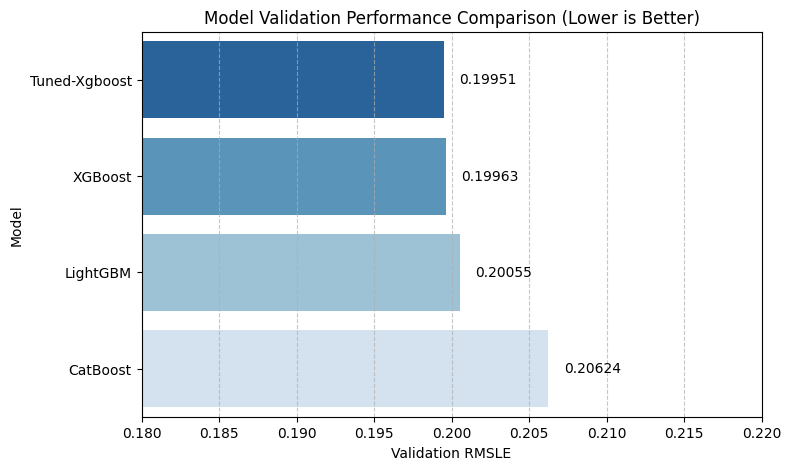

In [29]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x="Validation RMSE", 
    y="Model", 
    data=comparison, 
    palette="Blues_r"
)

for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.001, 
        p.get_y() + p.get_height() / 2, 
        f"{width:.5f}", 
        ha="left", 
        va="center"
    )

plt.title("Model Validation Performance Comparison (Lower is Better)")
plt.xlim(0.18, 0.22)
plt.xlabel("Validation RMSLE")
plt.ylabel("Model")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Three ensemble models LightGBM, CatBoost, and XGBoost were trained and compared on the same preprocessed dataset.
XGBoost achieved the best validation performance after hyperparameter tuning and was selected as the final model.
Feature engineering introduced date  and age related variables to provide additional information to the models, while preprocessing steps such as handling missing values and log-transforming the target variable helped prepare the data for training.
Feature importance analysis indicated which variables contributed most to the predictions and provided insight into the factors influencing equipment selling prices.

# Feature Importance Analysis

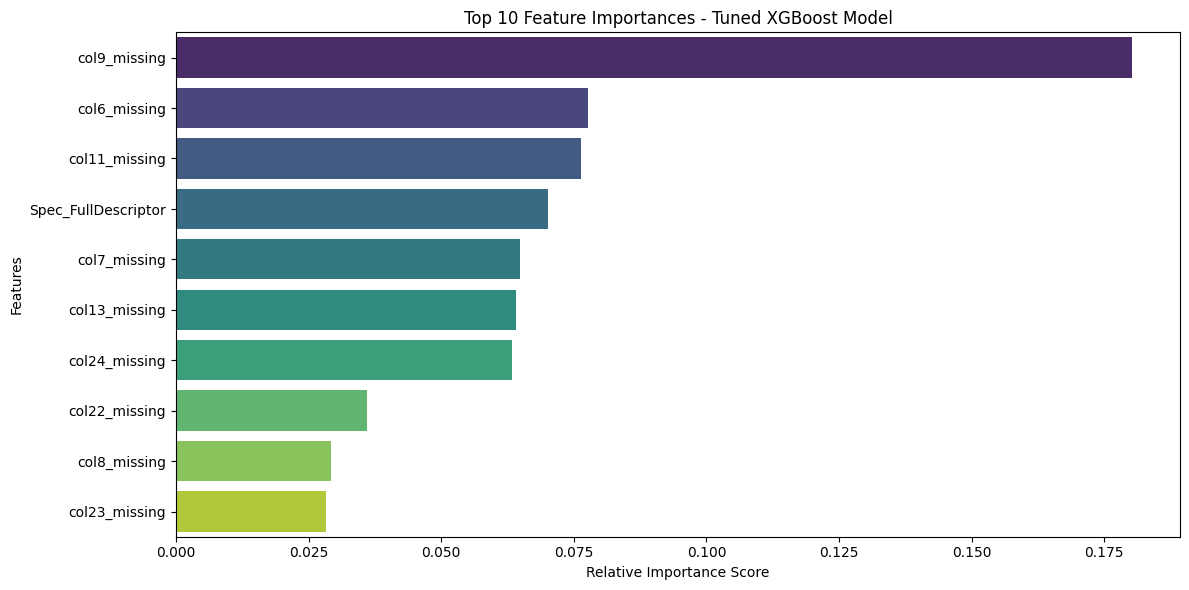

In [30]:
importances = tuned_xgb.feature_importances_
feature_names = X_tr.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices[:10]], y=feature_names[indices[:10]], palette="viridis")
plt.title('Top 10 Feature Importances - Tuned XGBoost Model')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()



The feature importance analysis shows that both original features and engineered features contribute to the model's performance. In addition, the missing indicator features play an important role, suggesting that missing values contain meaningful information rather than being random. These insights help explain how the tuned XGBoost model makes its predictions.

In [31]:
test_preds_xgb = tuned_xgb.predict(X_te)
final_prices = np.exp(test_preds_xgb)  

submission = pd.DataFrame({
    "TransactionID": test_df["TransactionID"],
    "TargetValue": final_prices
})

submission.to_csv("submission.csv", index=False)
print("submission.csv sucessful")
print(submission.head())

submission.csv sucessful
   TransactionID   TargetValue
0        1139307  67090.210938
1        1139419  77744.921875
2        1139482  31465.638672
3        1139522  20010.982422
4        1139684  12799.688477


# Milestone 1 

In [32]:
# import pandas as pd

# # Load datasets
# train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)
# test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv', low_memory=False)

# # Section 1: Basic Dataset Understanding
# print("Q1 (Dimensions):", f"Train: {len(train):,} | Test: {len(test):,}")
# print("Q2 (Target Variable):", set(train.columns) - set(test.columns))
# print("Q3 (Numerical Features):", len(train.select_dtypes(include=['int64', 'float64']).columns))

# # Section 2: Missing Value Analysis
# missing_pct = train.isnull().mean() * 100
# print("Q4 (Sparse > 90%):", list(missing_pct[missing_pct > 90].index))
# print("Q5 (Missing % OperationalHoursMeter):", round(missing_pct['OperationalHoursMeter'], 2))

# # Section 3: Target Variable Distribution & Anomalies
# print("Q6 (Median TargetValue):", f"${train['TargetValue'].median():,.0f}")
# print("Q7 (Mode ManufactureYear):", train['ManufactureYear'].mode()[0])
# print("Q8 (Earliest TransactionDate):", train['TransactionDate'].min())

# # Section 4: Categorical & High Cardinality Profiling
# print("Q9 (Unique Spec_BaseClass):", train['Spec_BaseClass'].nunique())
# print("Q10 (Top RegionCode):", train['RegionCode'].mode()[0])

# top_region = train['RegionCode'].mode()[0]
# avg_price_fl = train[train['RegionCode'] == top_region]['TargetValue'].mean()
# print("Q11 (Avg TargetValue Florida):", round(avg_price_fl, 2))

# print("Q12 (Top UtilizationTier):", train['UtilizationTier'].mode()[0])

# corr = train[['TargetValue', 'OperationalHoursMeter']].corr().iloc[0, 1]
# print("Q13 (Pearson Corr):", round(corr, 4))

# print("Q14 (Top Machinery Description):", train['FunctionalClassification'].mode()[0])

# Milestone 2

In [33]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# # Load raw train dataset
# df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)

# # --- Section 1: Feature Engineering ---
# dt = pd.to_datetime(df['TransactionDate'])
# df['TransactionYear'] = dt.dt.year
# df['TransactionQuarter'] = dt.dt.quarter
# df['AssetAge'] = df['TransactionYear'] - df['ManufactureYear']
# df['DescriptorLength'] = df['Spec_FullDescriptor'].fillna('').astype(str).str.len()
# df['HasOperationalHours'] = df['OperationalHoursMeter'].notnull().astype(int)
# df['HasVariantModifier'] = df['Spec_VariantModifier'].notnull().astype(int)

# print("Q1 (Mode AssetAge):", df['AssetAge'].mode()[0])
# print("Q2 (Quarter with Highest Avg TargetValue):", df.groupby('TransactionQuarter')['TargetValue'].mean().idxmax())
# print("Q3 (Max DescriptorLength):", df['DescriptorLength'].max())
# print("Q4 (HasOperationalHours == 1 Count):", df['HasOperationalHours'].sum())
# print("Q5 (% Records with Variant Info):", f"{df['HasVariantModifier'].mean()*100:.2f}%")
# print("Q6 (Mean ManufactureYear):", f"{df['ManufactureYear'].mean():.2f}")

# # --- Section 2: Encoding ---
# ohe_df = pd.get_dummies(df[['RegionCode', 'CabinType', 'UtilizationTier']], drop_first=True)
# print("Q7 (Encoded Columns Created):", ohe_df.shape[1])

# # --- Section 3: Correlation Analysis ---
# num_cols = df.select_dtypes(include=['int64', 'float64']).columns
# top_corr_feat = df[num_cols].corr()['TargetValue'].abs().sort_values(ascending=False).index[1]
# print("Q8 (Highest Abs Corr Feature):", top_corr_feat)

# # --- Section 4: Train-Validation Split ---
# X = pd.concat([df[num_cols].drop(columns=['TargetValue']), ohe_df], axis=1)
# y = df['TargetValue']
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# print("Q9 (Train Dataset Shape):", X_train.shape)
# print("Q10 (Validation Dataset Shape):", X_val.shape)

# # --- Section 5: Model Building & Evaluation ---
# predictors = ['ManufactureYear', 'AssetAge']
# imputer = SimpleImputer(strategy='mean')
# scaler = StandardScaler()

# X_tr_imp = imputer.fit_transform(X_train[predictors])
# X_val_imp = imputer.transform(X_val[predictors])

# X_tr_scaled = scaler.fit_transform(X_tr_imp)
# X_val_scaled = scaler.transform(X_val_imp)

# model = LinearRegression()
# model.fit(X_tr_scaled, y_train)
# r2 = r2_score(y_val, model.predict(X_val_scaled))

# print("Q11 (Validation R² Score):", f"{r2:.4f}")

# Milestone 3

In [34]:
# import pandas as pd
# import numpy as np

# # Load raw train dataset
# df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)

# # --- Datetime Extraction & Asset Age ---
# df['SaleYear'] = pd.to_datetime(df['TransactionDate']).dt.year
# m_year = df['ManufactureYear'].replace([1000, 1001], np.nan)
# df['AssetAge'] = df['SaleYear'] - m_year

# print("Q1 (SaleYear Mode):", df['SaleYear'].mode()[0])
# print("Q2 (Median AssetAge):", df['AssetAge'].median())

# # --- Feature Interaction (Intensity) ---
# hours_per_year = (df['OperationalHoursMeter'] / df['AssetAge']).replace([np.inf, -np.inf], np.nan)
# print("Q3 (Median HoursPerYear):", f"~{hours_per_year.median():.0f} hours/year")

# # --- Sparse Feature Dropping (>80% missing) ---
# sparse_cols = df.columns[df.isnull().mean() > 0.80]
# print("Q4 (Sparse Columns Dropped):", len(sparse_cols))

# # --- Categorical Imputation Check ---
# cabin_missing_count = df['CabinType'].isnull().sum()
# print("Q6 ('Missing' rows in CabinType):", cabin_missing_count)

# print("Q7 (X_train rows 80% split):", f"{int(len(df)*0.8):,} rows")

# # --- Ordinal Encoding Unique Values ---
# util_categories = df['UtilizationTier'].fillna('Unspecified').nunique()
# print("Q10 (Ordinal Encoded Unique Values):", util_categories)

# # --- Log Transformation Std ---
# log_target = np.log1p(df['TargetValue'])
# print("Q11 (Log Transformed Target Std):", f"~{log_target.std():.2f}")

# Milestone 4

In [35]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
# from sklearn.neural_network import MLPRegressor
# from sklearn.metrics import mean_absolute_error

# # Load dataset
# df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)

# # --- Q1: Stratified vs. Non-Stratified Split ---
# df['UtilizationTier'] = df['UtilizationTier'].fillna('Unknown')
# df['PriceBand'] = pd.qcut(df['TargetValue'], q=5, labels=False)

# _, val_s = train_test_split(df, test_size=0.3, random_state=42, stratify=df['PriceBand'])
# _, val_ns = train_test_split(df, test_size=0.3, random_state=42, stratify=None)

# prop_s = val_s['PriceBand'].value_counts().sort_index().to_numpy() / len(val_s)
# prop_ns = val_ns['PriceBand'].value_counts().sort_index().to_numpy() / len(val_ns)
# max_diff = np.max(np.abs(prop_s - prop_ns))
# print(f"Q1 (Max Abs Difference): {max_diff:.4f}")

# # --- Q2: Preprocessing Pipeline ---
# cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"]
# num_cols = ["ManufactureYear", "OperationalHoursMeter"]

# X_tr, X_val, y_tr, y_val = train_test_split(
#     df[cat_cols + num_cols], df['TargetValue'], test_size=0.3, random_state=42, stratify=df['PriceBand']
# )

# preprocessor = ColumnTransformer(transformers=[
#     ('cat', Pipeline([('imp', SimpleImputer(strategy="most_frequent")), ('ohe', OneHotEncoder(handle_unknown="ignore", sparse_output=True))]), cat_cols),
#     ('num', Pipeline([('imp', SimpleImputer(strategy="mean")), ('scaler', StandardScaler())]), num_cols)
# ], remainder="drop")

# X_tr_proc = preprocessor.fit_transform(X_tr)
# X_val_proc = preprocessor.transform(X_val)
# print(f"Q2 (Sum of X_train_proc): {float(X_tr_proc.sum()):.3f}")

# # --- Q3: Hyperparameter Tuning ---
# rf_search = RandomizedSearchCV(
#     RandomForestRegressor(random_state=42, n_jobs=-1),
#     param_distributions={'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 15]},
#     n_iter=5, cv=3, random_state=42, n_jobs=-1
# ).fit(X_tr_proc, y_tr)
# print(f"Q3 (Best n_estimators): {rf_search.best_params_['n_estimators']}")

# # --- Q4: AdaBoost Error Variance ---
# ada = AdaBoostRegressor(n_estimators=50, random_state=42).fit(X_tr_proc, y_tr)
# print(f"Q4 (AdaBoost Error Variance): {np.var(ada.estimator_errors_):.4f}")

# # --- Q5: Feature Importance ---
# rf100 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1).fit(X_tr_proc, y_tr)
# print(f"Q5 (Max Feature Importance Index): {np.argmax(rf100.feature_importances_)}")

# # --- Q6: Counting MLP Weights ---
# N = X_tr_proc.shape[1]
# weights = (N * 128) + (128 * 64) + (64 * 32) + (32 * 1)
# print(f"Q6 (Total MLP Connection Weights): {weights}")

# # --- Q7: MLP Training Loss ---
# mlp7 = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation="relu", solver="adam", max_iter=5, batch_size=32, random_state=42).fit(X_tr_proc, y_tr)
# print(f"Q7 (MLP Training Loss): {mlp7.loss_:.4f}")

# # --- Q8: Effect of Regularization (alpha) ---
# mlpa = MLPRegressor(hidden_layer_sizes=(100,), max_iter=5, alpha=0.0001, random_state=42).fit(X_tr_proc, y_tr)
# mlpb = MLPRegressor(hidden_layer_sizes=(100,), max_iter=5, alpha=1.0, random_state=42).fit(X_tr_proc, y_tr)
# mae_diff = abs(mean_absolute_error(y_tr, mlpa.predict(X_tr_proc)) - mean_absolute_error(y_tr, mlpb.predict(X_tr_proc)))
# print(f"Q8 (MAE Difference due to Alpha): {mae_diff:.4f}")

# # --- Q9: Validation Performance ---
# val_mae = mean_absolute_error(y_val, mlp7.predict(X_val_proc))
# print(f"Q9 (Validation MAE): {val_mae:.4f}")

# Milestone 5

In [36]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.feature_selection import SelectKBest, f_regression
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# # Load dataset
# df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)

# # --- Section 1: Feature Engineering ---
# dt = pd.to_datetime(df['TransactionDate'])
# df['TransactionYear'] = dt.dt.year
# df['TransactionMonth'] = dt.dt.month
# df['TransactionQuarter'] = dt.dt.quarter
# df['ManufactureDecade'] = (df['ManufactureYear'] // 10) * 10
# df['SpecificationComplexity'] = df['Spec_FullDescriptor'].fillna('').astype(str).str.split().str.len()

# print(f"Q1 (Highest Avg TargetValue Decade): {df.groupby('ManufactureDecade')['TargetValue'].mean().idxmax()}")
# print(f"Q2 (Max SpecificationComplexity): {df['SpecificationComplexity'].max()}")

# # --- Section 2: Feature Selection ---
# cat_cols = ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'AssetScaleFactor', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription']
# all_num = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# num_cols = [c for c in all_num if c not in ['TransactionID', 'AssetID', 'TargetValue']]

# selected_features = cat_cols + num_cols
# print(f"Q3 (Number of Features in Training Data): {len(selected_features)}")

# # --- Section 3: Train-Validation Split ---
# X = df[selected_features]
# y = df['TargetValue']
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # --- Section 4: Data Preprocessing ---
# preprocessor = ColumnTransformer(transformers=[
#     ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
#     ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
# ])

# X_tr_proc = preprocessor.fit_transform(X_train)
# X_val_proc = preprocessor.transform(X_val)
# print(f"Q4 (Processed Training Dataset Shape): {X_tr_proc.shape}")

# # --- Section 5: Feature Selection (SelectKBest Top 100) ---
# selector = SelectKBest(score_func=f_regression, k=100)
# X_tr_kbest = selector.fit_transform(X_tr_proc, y_train)
# X_val_kbest = selector.transform(X_val_proc)

# feature_names = preprocessor.get_feature_names_out()
# scores = selector.scores_
# support = selector.get_support()

# best_idx = np.argmax(scores)
# print(f"Q5 (Highest F-score Feature): {feature_names[best_idx]}")

# selected_scores = [(feature_names[i], scores[i]) for i in np.where(support)[0]]
# selected_scores.sort(key=lambda x: x[1])
# print(f"Q6 (Lowest F-score among Selected): {selected_scores[0][0]}")

# removed = [feature_names[i] for i in np.where(~support)[0]]
# print(f"Q7 (Sample Removed Feature): {'cat__RegionCode_Oklahoma' in removed}")

# # --- Section 6: Baseline Model ---
# rf_base = RandomForestRegressor(random_state=42, n_jobs=-1).fit(X_tr_kbest, y_train)
# y_pred_base = rf_base.predict(X_val_kbest)
# print(f"Q8 (Baseline Validation MAE): {mean_absolute_error(y_val, y_pred_base):.2f}")
# print(f"Q9 (Baseline Validation RMSE): {root_mean_squared_error(y_val, y_pred_base):.2f}")

# # --- Section 7: Hyperparameter Tuning ---
# search = RandomizedSearchCV(
#     RandomForestRegressor(random_state=42, n_jobs=-1),
#     param_distributions={'n_estimators': [100, 200], 'max_depth': [10, None], 'max_features': ['sqrt']},
#     n_iter=4, cv=3, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1
# ).fit(X_tr_kbest, y_train)

# print(f"Q10 (Best n_estimators): {search.best_params_['n_estimators']}")
# print(f"Q11 (Best max_depth): {search.best_params_['max_depth']}")
# print(f"Q12 (Best Cross-Validation RMSE): {-search.best_score_:.2f}")

# y_pred_tuned = search.best_estimator_.predict(X_val_kbest)
# print(f"Q13 (Tuned Validation MAE): {mean_absolute_error(y_val, y_pred_tuned):.2f}")
# print(f"Q14 (Tuned Validation RMSE): {root_mean_squared_error(y_val, y_pred_tuned):.2f}")